Juupyter notebook for simple data analysis of output files from Gaussian, cdftT, pySCF (.cube and density matrix)

In [1]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os


def list2array(list_) :
    data = list()
    #for line in list_ :
    #    data.append(line.split())
    #data = np.array(data,dtype=np.float64).flatten()
    for line in list_ :
        data += line.split()
    data = np.array(data,dtype=np.float64)
    return data

def readRDM(fname,nMo) :
    with open(fname, 'r') as file:
        lines = file.readlines()

    alpha = list2array(lines[1:nMo+1])
    alpha.resize((nMo,nMo))

    beta = list2array(lines[nMo+3:2*nMo+3])
    beta.resize((nMo,nMo))

    return alpha,beta

In [97]:
#########################
# pyplot default values #
#########################

font = 15
plt.rcParams.update({
    'axes.labelsize': font,   # x and y labels
    'axes.titlesize': font+2,   # subplot titles
    'xtick.labelsize': font-1,  # x tick labels
    'ytick.labelsize': font-1,  # y tick labels
    'legend.fontsize': font-1,  # legends
    'font.size': font         # default font size
})

Get transitions used by pySCF (matrix elements of X produced by pySCF_DensityMatrix and pySCF_TransitionDensityMatrix)

In [487]:
fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_CO/clean_test/transitions/pySCF/X_state_11.npy"
py_X = np.load(fname)
nocc,nvir = np.shape(py_X)
print(f'n_occupied = {nocc}, n_virtual = {nvir} \n')

n_transitions = 10
a = np.abs(py_X)
for i in range(n_transitions):
    val = np.max(np.max(a))
    pos = np.argmax(a)
    print(f'transition {int(np.floor(pos/nvir)+1)}->{pos%nvir+nocc+1} with coef {val:.5f}')
    a[int(np.floor(pos/nvir)),pos%nvir]=0
print("")

with np.printoptions(precision=3,suppress=True):
    print(py_X)

n_occupied = 7, n_virtual = 3 

transition 7->10 with coef 0.49128
transition 4->10 with coef 0.44872
transition 6->9 with coef 0.15604
transition 5->8 with coef 0.15604
transition 3->10 with coef 0.09105
transition 6->8 with coef 0.01219
transition 5->9 with coef 0.01219
transition 2->10 with coef 0.00224
transition 1->10 with coef 0.00008
transition 3->9 with coef 0.00000

[[-0.    -0.     0.   ]
 [-0.     0.     0.002]
 [-0.     0.    -0.091]
 [-0.    -0.     0.449]
 [ 0.156 -0.012  0.   ]
 [ 0.012  0.156 -0.   ]
 [ 0.    -0.    -0.491]]


compare 2 RDM

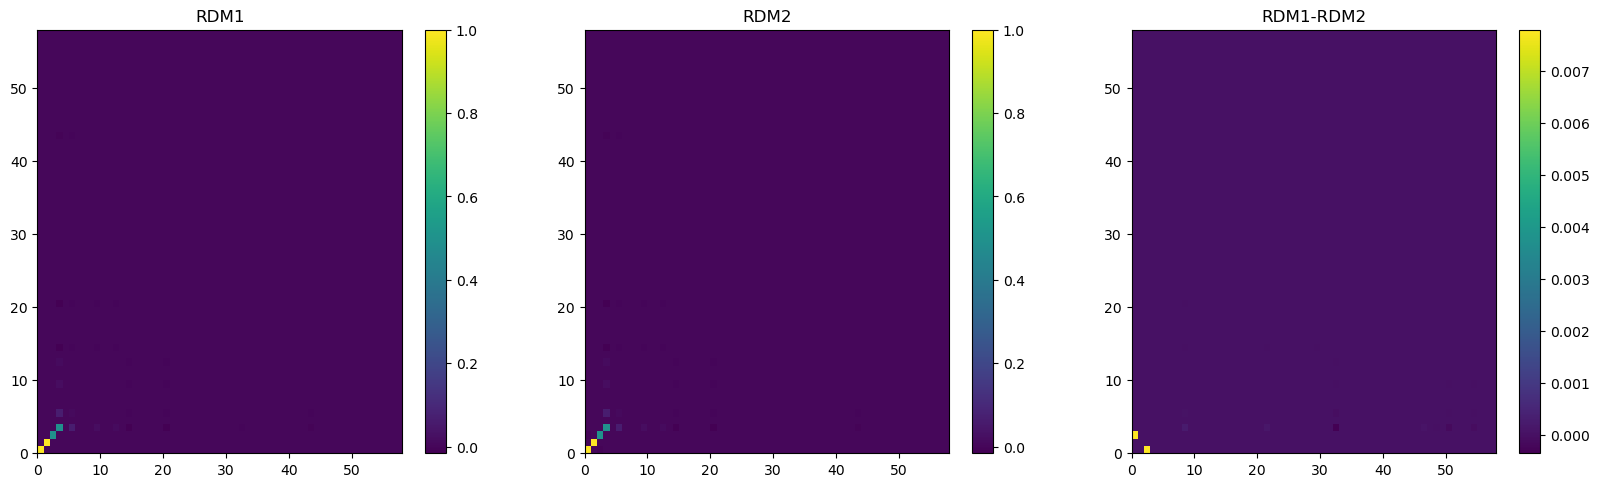

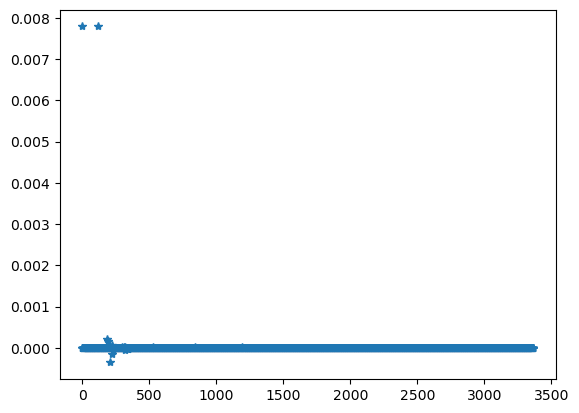

In [97]:
##################
# RDM from CdftT #
##################
#f1 = open("/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/cpp/cpp_Gamma_state50_RDM.cdftt")
#f1 = open("/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/SDLimit/cpp_Gamma_SDlimit005__state8_RDM.cdftt")
#f2 = open("/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/SDLimit/cpp_Gamma_SDlimit0__state8_RDM.cdftt")

f1 = open("/home/atourneur/Documents/data/fructose/cpp/Excited_states/cpp_Gamma__transition_state0_state1_RDM.cdftt")
f2 = open("/home/atourneur/Documents/data/fructose/cpp/Excited_states/cpp_X__transition_state0_state1_RDM.cdftt")

f1 = open("/home/atourneur/Documents/data/acrolein_runtime/test_optimized/cpp_Gamma_new_001__state1_RDM.cdftt")
f2 = open("/home/atourneur/Documents/data/acrolein_runtime/cpp_Gamma_new__state1_RDM.cdftt")

#f1 = open("/home/atourneur/Documents/data/acrolein_runtime/cpp_X_new__state1_RDM.cdftt")
#f2 = open("/home/atourneur/Documents/data/acrolein_runtime/cpp_Gamma_new__state1_RDM.cdftt")

Nmo = 80          # number of molecular orbitals i.e. size of matrix

tokens = f1.read().split()
data = []
for idx, token in enumerate(tokens):
    if idx >=2 :
        row = token
        data.append(row)
CdftTRDM1 = np.array(data[0:Nmo**2],dtype=float)*2

tokens = f2.read().split()
data = []
for idx, token in enumerate(tokens):
    if idx >=2 :
        row = token
        data.append(row)
CdftTRDM2 = np.array(data[0:Nmo**2],dtype=float)

CdftTRDM1.resize((Nmo,Nmo))
CdftTRDM2.resize((Nmo,Nmo))


##################
# RDM from pySCF #
##################
fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/pySCF/RDM_state_1.npy"
pyRDM = np.load(fname)



########
# plot #
########
RDM1 = CdftTRDM1[12:70,12:70]
RDM2 = CdftTRDM2[12:70,12:70]
RDM1 = RDM1/np.max(np.max(RDM1))
RDM2 = RDM2/np.max(np.max(RDM2))

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5.5))
plot1 = ax[0].pcolormesh(RDM1)
plt.colorbar(plot1)
plot2 = ax[1].pcolormesh(RDM2)
plt.colorbar(plot2)
plot3 = ax[2].pcolormesh(RDM1-RDM2)
plt.colorbar(plot3)
ax[0].set_title('RDM1')
ax[1].set_title('RDM2')
ax[2].set_title('RDM1-RDM2')
plt.show()


plt.plot(RDM1.flatten()/np.max(RDM1.flatten())-RDM2.flatten()/np.max(RDM2.flatten()),"*")
#plt.plot(RDM1.flatten(),'*')
#plt.plot(RDM2.flatten(),".")
#plt.yscale('log')
#plt.ylim([-0.001,0.001])
plt.show()

Transition matrix from Gaussian .fchk

In [67]:
# Gaussian .fchk file

#fchk_fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/input/acrolein_100.fchk"
fchk_fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/input/acrolein_100.fchk"
# CdftT file
#CdftT_fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/cpp/cpp_Gamma_transition_state0_state10_RDM.cdftt"
CdftT_fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/presentation/cpp_X__transition_state0_state10_RDM.cdftt"
# pySCF file
pySCF_fname = None #"/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/pySCF/T_RDM_state_10.npy"

##############
# read .fchk #
##############
nMo     = 80
nStates = 100
nSpins  = 2

#read gaussian fchk file
with open(fchk_fname, 'r') as file:
    lines = file.readlines()

i = 0
for line in lines:
    i += 1
    if line[0:22] == 'G to E trans densities' :
        start = i
    if line[0:16] == 'Mulliken Charges' :
        end = i-1
data = list2array(lines[start:end])

#resize to obtain 1 matrix per state and spin type
#trans_dens[spin,state] is a nMo x nMo transition density matrix corresponding to an excited state (0 indexed) and spin
trans_dens = np.empty(shape=(nSpins,nStates,nMo,nMo))
for state in range(nStates) :
    for spin in range(nSpins) :
        k = nSpins*state + spin
        tmp = data[nMo**2*k:nMo**2*(k+1)]
        tmp.resize((nMo,nMo))
        trans_dens[spin,state] = tmp

#read MO coefficients matrix to for MO->AO conversion of CdftT RDM 
i = 0
beta_read = False  # check if alphas and betas treated separately
for line in lines:
    i += 1
    if line[0:21] == 'Alpha MO coefficients' :
        startA = i
    if line[0:20] == 'Beta MO coefficients' :
        startB = i
        beta_read = True
    if line[0:17] == 'Orthonormal basis' :
        orthobasis = i
        
if beta_read :
    AlphaMoCoefs = list2array(lines[startA:startB-1])
    AlphaMoCoefs.resize((nMo,nMo))
    BetaMoCoefs  = list2array(lines[startB:2*startB-startA-1])
    BetaMoCoefs.resize((nMo,nMo))
else :
    AlphaMoCoefs = list2array(lines[startA:orthobasis-1])
    AlphaMoCoefs.resize((nMo,nMo))
    BetaMoCoefs = AlphaMoCoefs
    AlphaMoCoefs2 = list2array(lines[orthobasis:orthobasis+(orthobasis-startA)-1])
    AlphaMoCoefs2.resize((nMo,nMo))

#########################
# read CdftT RDM matrix #
#########################
alphaGamma,betaGamma = readRDM(CdftT_fname,nMo)

#########################
# read pySCF RDM matrix #
#########################
if pySCF_fname!=None:
    pySCF_trans_dens = np.load(pySCF_fname)
else:
    pySCF_trans_dens = np.empty(0)

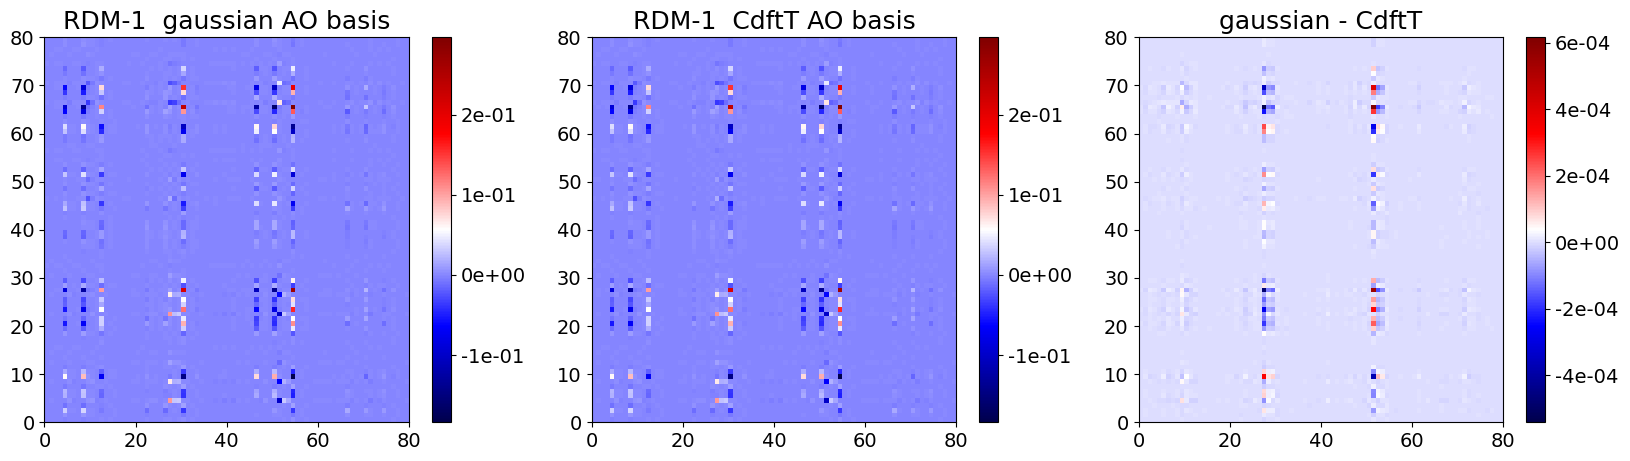

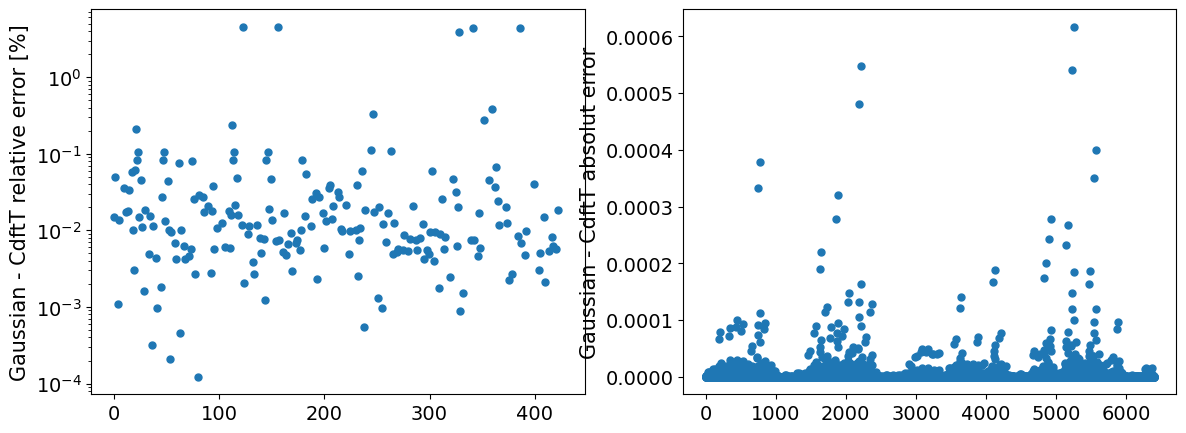

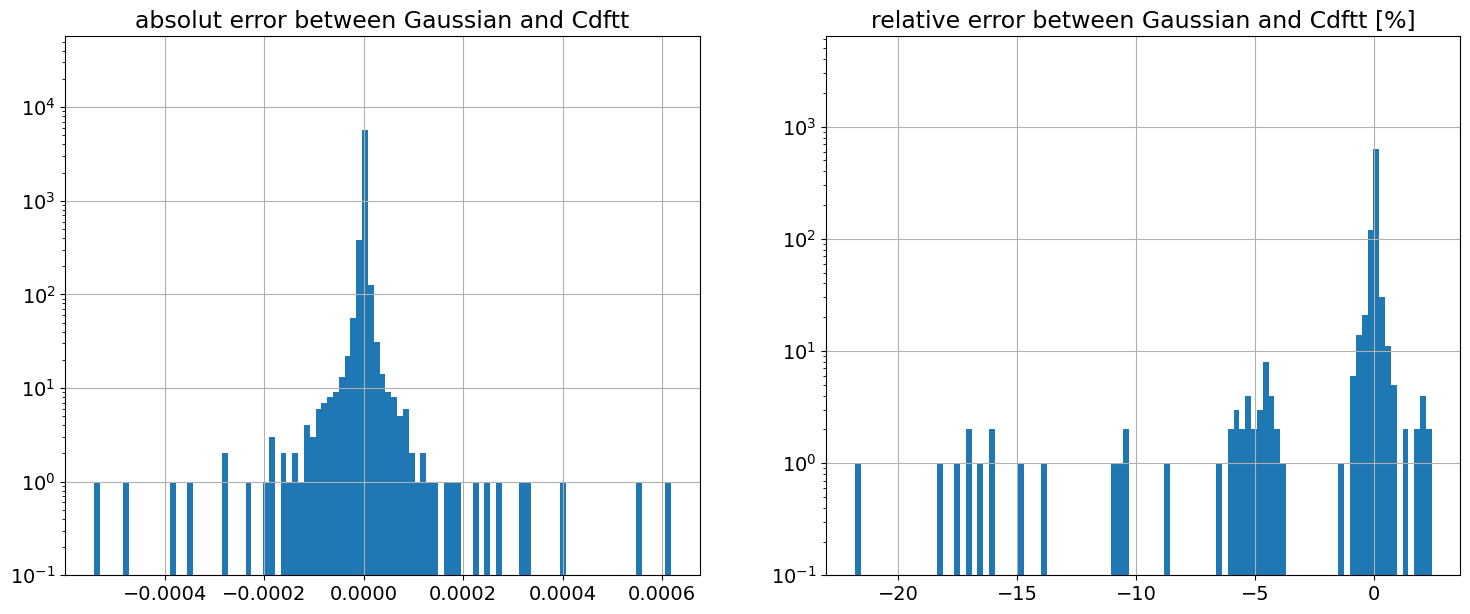

In [110]:
#####################################
# compare Gaussian-CdftT (AO basis) #
#####################################

#choose a Gaussian RDM
alphaG = trans_dens[0,9]
betaG  = trans_dens[1,9]

#convert MO to AO for CdftT RDM
AO_alphaGamma = np.matmul(np.matmul(np.transpose(AlphaMoCoefs),alphaGamma),AlphaMoCoefs)
AO_betaGamma = np.matmul(np.matmul(np.transpose(BetaMoCoefs),betaGamma),BetaMoCoefs)

#get same norm on Gaussian and CdftT
normac = np.sqrt(np.sum(AO_alphaGamma**2))
normag = np.sqrt(np.sum(alphaG**2))
AO_alphaGamma *= normag/normac
normbc = np.sqrt(np.sum(AO_betaGamma**2))
normbg = np.sqrt(np.sum(betaG**2))
AO_betaGamma *= normbg/normbc

plot = 'alpha'
fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5))
if plot=='alpha':
    plot1 = ax[0].pcolormesh(alphaG,cmap = 'seismic')
    plot2 = ax[1].pcolormesh(AO_alphaGamma,cmap = 'seismic')
    plot3 = ax[2].pcolormesh(alphaG-AO_alphaGamma,cmap = 'seismic')
    ax[0].set_title('RDM-1  gaussian AO basis',fontsize=18)
    ax[1].set_title('RDM-1  CdftT AO basis',fontsize=18)
if plot=='beta':
    plot1 = ax[0].pcolormesh(betaG)
    plot2 = ax[1].pcolormesh(AO_betaGamma)
    plot3 = ax[2].pcolormesh(betaG-AO_betaGamma)
    ax[0].set_title('gaussian AO beta')
    ax[1].set_title('CdftT AO Gamma beta')

plt.colorbar(plot1, format='%.0e')
plt.colorbar(plot2, format='%.0e')
plt.colorbar(plot3, format='%.0e')

ax[2].set_title('gaussian - CdftT',fontsize=18)

plt.show()

treshold = 0.005  #consider only coefs above treshold for relative error
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(14,5))
ax[0].plot(np.abs(alphaG[np.abs(alphaG)>treshold].flatten()-AO_alphaGamma[np.abs(alphaG)>treshold].flatten())/alphaG[np.abs(alphaG)>treshold].flatten()*100,'.')
ax[0].set_ylabel('Gaussian - CdftT relative error [%]')
ax[0].set_yscale('log')
ax[1].plot(np.abs(alphaG.flatten()-AO_alphaGamma.flatten()),'.')
ax[1].set_ylabel('Gaussian - CdftT absolut error')
plt.show()

####################
# create histogram #
####################

#densitycpp = -densitycpp
treshold = 1e-3
err = (alphaG.flatten() - AO_alphaGamma.flatten())
rel_err = err[np.abs(alphaG.flatten())>treshold]/alphaG.flatten()[np.abs(alphaG.flatten())>treshold]*100

scale = 'log'  #log or linear
bins     = np.linspace(np.min(err),np.max(err),100)
rel_bins = np.linspace(np.min(rel_err),np.max(rel_err),100)

fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(18,7))
plot1 = ax[0].hist(err,bins=bins)
plot2 = ax[1].hist(rel_err,bins=rel_bins)
if scale=='log':
    ax[0].set_ylim([0.1,plot1[0].max()*10.1])
    ax[1].set_ylim([0.1,plot2[0].max()*10.1])
if scale=='linear':
    ax[0].set_ylim([0.1,plot1[0].max()*1.1])
    ax[1].set_ylim([0.1,plot2[0].max()*1.1])
ax[0].set_title("absolut error between Gaussian and Cdftt")
ax[1].set_title("relative error between Gaussian and Cdftt [%]")
ax[0].set_yscale(scale)
ax[1].set_yscale(scale)
ax[0].grid()
ax[1].grid()
plt.show()

In [ ]:
##################################
# compare pySCF-CdftT (MO basis) #
##################################
norma = np.sqrt(np.sum(alphaGamma**2))
normb = np.sqrt(np.sum(betaGamma**2))
alphaGamma/=norma
betaGamma/=normb

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5))
plot1 = ax[0].pcolormesh(pySCF_trans_dens)
plot2 = ax[1].pcolormesh(alphaGamma)
plot3 = ax[2].pcolormesh(pySCF_trans_dens-alphaGamma)
plt.colorbar(plot1)
plt.colorbar(plot2)
plt.colorbar(plot3)
ax[0].set_title('pySCF')
ax[1].set_title('cpp MO')
ax[2].set_title('pySCF - CdftT')
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(20,7.5))
ax[0].plot(pySCF_trans_dens.flatten(),'*',label='pySCF')
ax[0].plot(alphaGamma.flatten(),'.',label='alphaGamma')
ax[0].plot(betaGamma.flatten(),'.',label='betaGamma')
ax[0].legend()
ax[1].plot(pySCF_trans_dens.flatten()-alphaGamma.flatten())
ax[1].set_ylabel('pySCF - CdftT')
plt.show()


CUBE file comparison

In [127]:
########################
# read both cube files #
########################
#f1 = open("/home/atourneur/Documents/data/fructose/cpp/Excited_states/cpp_X__state1.cube")
#f2 = open("/home/atourneur/Documents/data/fructose/cpp/Excited_states/cpp_X__001__state1.cube")
f1 = open("/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/last_version/cpp_Gamma__state10.cube")
f2= open("/home/atourneur/Documents/CdftT/test_ambroise/test_acrolein/Gaussian/acroleinEx10.cube")
#f2 = open("/home/atourneur/Documents/data/C30O26H52/input/C30O26H52_Ex1.cube")

tokens = f1.read().split()
data = []
for idx, token in enumerate(tokens):
    if idx >=32 :                            #ignore header
        row = token
        data.append(row)
densitycpp = np.array(data,dtype=float)

tokens = f2.read().split()
data = []
for idx, token in enumerate(tokens):
    if idx >=38:
        row = token
        data.append(row)
densitygaussian = np.array(data,dtype=float)

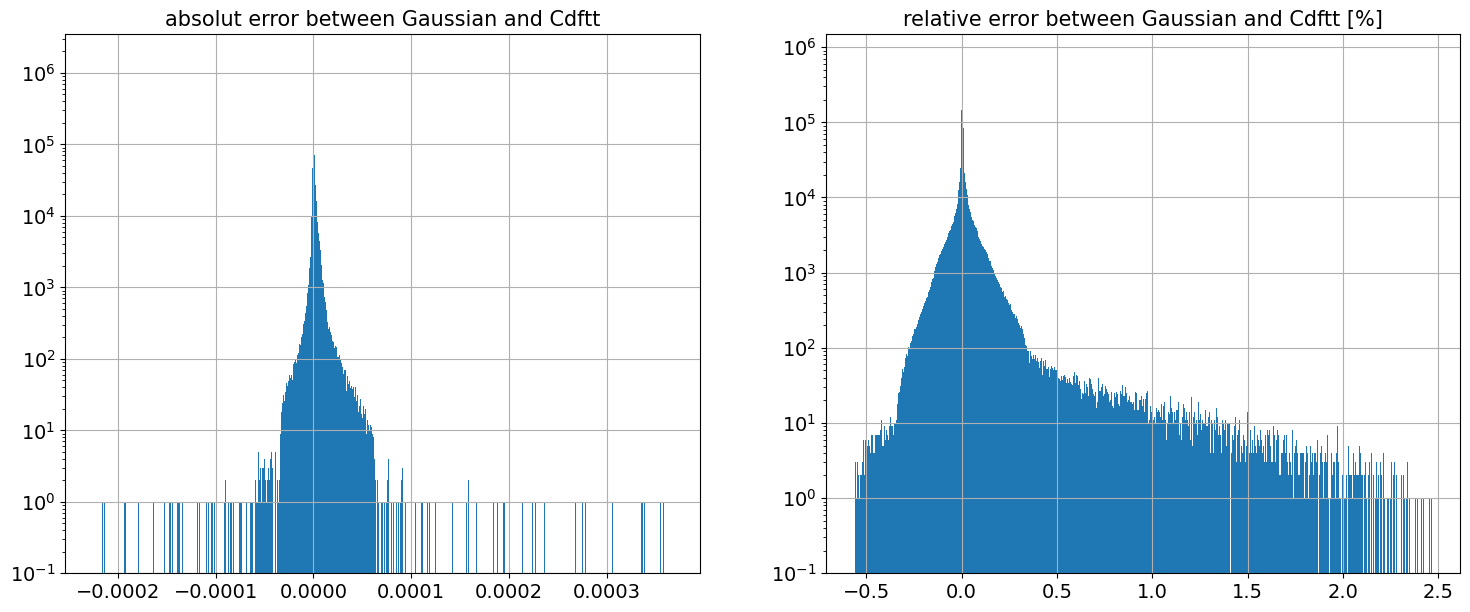

In [128]:
####################
# create histogram #
####################



#densitycpp = -densitycpp
treshold = 1e-8
err = (densitycpp - densitygaussian)
rel_err = err[np.abs(densitygaussian)>treshold]/densitygaussian[np.abs(densitygaussian)>treshold]*100

scale = 'log'  #log or linear
bins     = np.linspace(np.min(err)*.1,np.max(err)*.1,750)
rel_bins = np.linspace(np.min(rel_err),np.max(rel_err),750)

fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(18,7))
plot1 = ax[0].hist(err,bins=bins)
plot2 = ax[1].hist(rel_err,bins=rel_bins)
if scale=='log':
    ax[0].set_ylim([0.1,plot1[0].max()*10.1])
    ax[1].set_ylim([0.1,plot2[0].max()*10.1])
if scale=='linear':
    ax[0].set_ylim([0.1,plot1[0].max()*1.1])
    ax[1].set_ylim([0.1,plot2[0].max()*1.1])
ax[0].set_title("absolut error between Gaussian and Cdftt",fontsize=15)
ax[1].set_title("relative error between Gaussian and Cdftt [%]",fontsize=15)
ax[0].set_yscale(scale)
ax[1].set_yscale(scale)
ax[0].grid()
ax[1].grid()
plt.show()

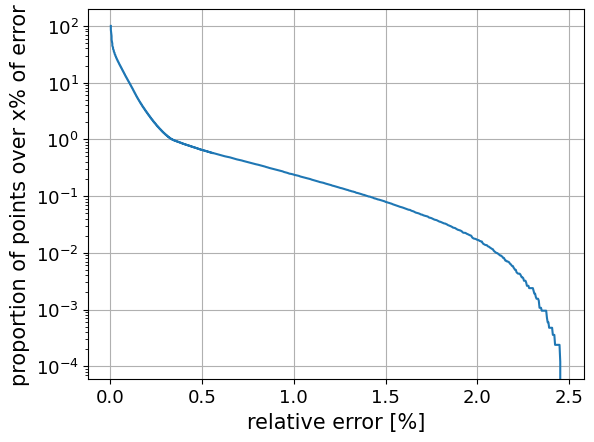

In [95]:
count,x = np.histogram(rel_err,rel_bins)
argsortx = np.argsort(np.abs(x))

cumul_count = []
for i in range(np.size(count)):
    cumul_count.append(np.sum(count[argsortx[0:i]]))

plt.plot(np.abs(x[argsortx[:-1]]),(1-cumul_count/cumul_count[-1])*100)
plt.yscale('log')
plt.xlabel('relative error [%]',fontsize = 15)
plt.ylabel("proportion of points over x% of error",fontsize = 15)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.grid('on')

Read .fchk GS electronic density

In [516]:
################################################################
# convert upper triangular list of coefs into symmetric matrix #
################################################################

fchk_fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_CO/clean_test/input/CO_TDDFT_STO-3G_TDA_SCF_CUBE.fchk"
nMo = 10

#read gaussian fchk file
with open(fchk_fname, 'r') as file:
    lines = file.readlines()

i=0
for line in lines:
    i += 1
    if line[0:17] == 'Total SCF Density' :
        start = i
    if line[0:12] == 'Total CI Rho' :
        end = i-1
GSAOdensity_flat = list2array(lines[start:end])

GSAOdensity      = np.zeros(shape=(nMo,nMo))
p = 0
k = 0
l = nMo
for p in range(nMo):
    GSAOdensity[p:,p]= GSAOdensity_flat[k:k+l]
    k=k+l
    l-=1
for p in range(nMo):
    for q in range(nMo) :
        if p>q :
            GSAOdensity[q,p] = GSAOdensity[p,q]


with np.printoptions(precision=8,suppress=True,linewidth=250):
    print(GSAOdensity)
                

[[ 2.11924873 -0.45945299  1.97310533  0.          0.          0.44852936  0.          0.          0.          0.44852936]
 [-0.45945299  0.13409584 -0.66241044  0.          0.          0.64774137  0.00995669  0.0315648   0.          0.        ]
 [ 1.97310533 -0.66241044 -0.0680621   2.11162208  0.00952261 -0.36069747  0.          0.          0.10955167 -0.46638818]
 [ 0.          0.          2.11162208  2.08492328  0.          0.          0.73302103  0.          0.          0.        ]
 [ 0.          0.          0.00952261  0.          0.          1.19795908  0.          0.          0.          0.73302103]
 [ 0.44852936  0.64774137 -0.36069747  0.          1.19795908  0.          0.          0.          0.          1.19795908]
 [ 0.          0.00995669  0.          0.73302103  0.          0.          0.10735336 -0.0598944   0.          0.        ]
 [ 0.          0.0315648   0.          0.          0.          0.         -0.0598944  -0.68023494 -0.07732454  0.4697975 ]
 [ 0.          0

runtime and parallelisatoin

srunNode cl24 1 64, 64cores 32 cores per socket cpu


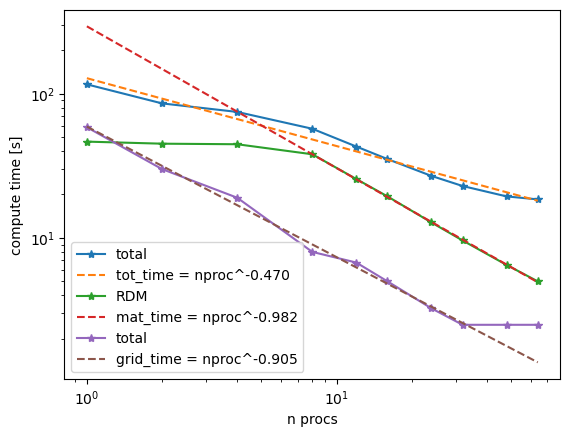

Text(0.5, 1.0, 'compute time x nprocs')

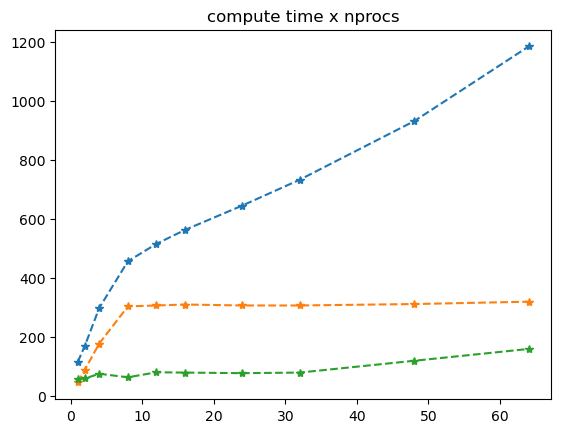

In [63]:
print('srunNode cl24 1 64, 64cores 32 cores per socket cpu')
nproc = np.array([1,2,4,8,12,16,24,32,48,64])
total_time = np.array([116,85.6,74.7,57.1,43,35.2,26.9,22.9,19.4,18.5])
matrix_time = np.array([46.5,45,44.6,38,25.6,19.4,12.8,9.6,6.5,5])
grid_time = np.array([11.7,6,3.8,1.6,1.35,1,0.65,0.5,0.5,0.5])*5

f = np.polyfit(np.log(nproc),np.log(total_time),1)
total_time_fit = np.exp(f[0]*np.log(nproc)+f[1])
label1 = f'tot_time = nproc^{f[0]:.3f}'
f = np.polyfit(np.log(nproc[3:]),np.log(matrix_time[3:]),1)
matrix_time_fit = np.exp(f[0]*np.log(nproc)+f[1])
label2 = f'mat_time = nproc^{f[0]:.3f}'
f = np.polyfit(np.log(nproc[:-2]),np.log(grid_time[:-2]),1)
grid_time_fit = np.exp(f[0]*np.log(nproc)+f[1])
label3 = f'grid_time = nproc^{f[0]:.3f}'


plt.plot(nproc,total_time,'*-',label='total')
plt.plot(nproc,total_time_fit,'--',label=label1)
plt.plot(nproc,matrix_time,'*-',label='RDM')
plt.plot(nproc,matrix_time_fit,'--',label=label2)
plt.plot(nproc,grid_time,'*-',label='total')
plt.plot(nproc,grid_time_fit,'--',label=label3)
plt.xlabel('n procs')
plt.ylabel('compute time [s]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

plt.plot(nproc,np.array(total_time)*np.array(nproc),'*--',label='total')
plt.plot(nproc,np.array(matrix_time)*np.array(nproc),'*--',label='RDM')
plt.plot(nproc,np.array(grid_time)*np.array(nproc),'*--',label='grid')
plt.title('compute time x nprocs')

Runtime analysis (from .out file using lynx)

In [8]:
fname_prefix = "/home/atourneur/Documents/data/fructose/cpp/new_runtime/Gamma_noCutoff"
nthread = [1,2,4,6,8,12,16,24,32,48,64,96]

t_mat_vec = []
t_grid_vec = []
t_write_grid_vec = []
t_tot = []
t_const = []
for i in nthread:
    fname = fname_prefix + "/xrun" + str(i) + "" + ".out"

    t_mat = 0
    t_grid = 0
    t_write_grid = 0
    with open(fname, 'r') as file:
        lines = file.readlines()

    for line in lines:
        if line[0:49]=="Total number of electronic densities to compute: ": nb_elec_dens = int(line[49:])
        if line[0:25]=="compute time of matrix : ":        t_mat        += float(line[25:-2])
        if line[0:23]=="compute time of grid : ":          t_grid       += float(line[23:-2])
        if line[0:32]=="compute time of writting grid : ": t_write_grid += float(line[32:-2])
        if line[0:49]=="Total number of transition densities to compute: ": nb_tran_dens = int(line[49:])
        
    t_mat_vec.append(np.sum(np.array(t_mat)))
    t_grid_vec.append(t_grid)
    t_write_grid_vec.append(t_write_grid)

    t_const.append(float(lines[-4][24:-2])+float(lines[-5][33:-2])+float(lines[-6][26:-2])+float(lines[-7][24:-2])+float(lines[-8][21:-2])+t_write_grid)
    t_tot.append(float(lines[-1][12:])/1000.0)
    

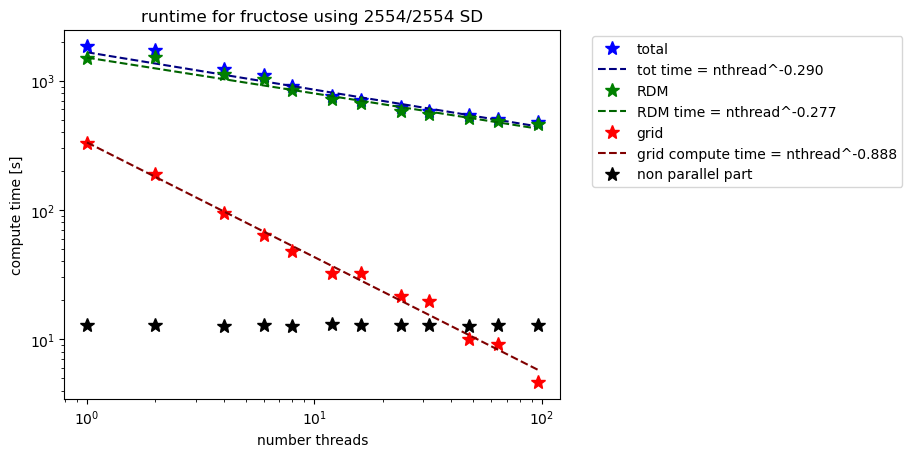

In [9]:
f = np.polyfit(np.log(nthread[3:]),np.log(t_tot[3:]),1)
total_time_fit = np.exp(f[0]*np.log(nthread)+f[1])
label1 = f'tot time = nthread^{f[0]:.3f}'
f = np.polyfit(np.log(nthread[3:]),np.log(t_mat_vec[3:]),1)
matrix_time_fit = np.exp(f[0]*np.log(nthread)+f[1])
label2 = f'RDM time = nthread^{f[0]:.3f}'
f = np.polyfit(np.log(nthread),np.log(t_grid_vec),1)
grid_time_fit = np.exp(f[0]*np.log(nthread)+f[1])
label3 = f'grid compute time = nthread^{f[0]:.3f}'
f = np.polyfit(np.log(nthread),np.log(t_write_grid_vec),1)
grid_write_time_fit = np.exp(f[0]*np.log(nthread)+f[1])
label4 = f'grid save time = nthread^{f[0]:.3f}'


mpl.rcParams['lines.markersize']=10

plt.plot(nthread,t_tot,'*',color='blue',label='total')
plt.plot(nthread,total_time_fit,'--',color='navy',label=label1)
plt.plot(nthread,t_mat_vec,'*',color='green',label='RDM')
plt.plot(nthread,matrix_time_fit,'--',color='darkgreen',label=label2)
plt.plot(nthread,t_grid_vec,'*',color='red',label='grid')
plt.plot(nthread,grid_time_fit,'--',color='maroon',label=label3)
#plt.plot(nthread,np.array(t_write_grid_vec),'*',color='magenta',label="save grid")
#plt.plot(nthread,grid_write_time_fit,'--',color='darkmagenta',label=label4)
plt.plot(nthread,np.array(t_const),'*',color='black',label="non parallel part")
plt.xlabel('number threads')
plt.ylabel('compute time [s]')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05,1))
plt.title("runtime for fructose using 2554/2554 SD")

plt.show()

SD distribution

In [120]:
fname = "/home/atourneur/Documents/data/fructose/input/fructose100.log"
with open(fname, 'r') as file:
    lines = file.readlines()

i=0
istart = []
state = []
coef = []
for line in lines:
    if line[0:15]==" Excited State ": 
        state.append(np.array(coef))
        coef = []
    if line.find("->")!=-1:
        coef.append(float(line[-7:]))

    i+=1
    if line[0:15]==" Excited State ":
        istart.append(i+1)
    if line =="            Population analysis using the SCF Density.":
        istart.append(i-9)

out = f''
for i in range(1,np.size(np.array(istart))):
        tmpstr = f'Ex {i} -> {istart[i]-istart[i-1]} SD; '
        out += tmpstr
        if i%6==5:
             out+='\n'
print(out)

Ex 1 -> 2505 SD; Ex 2 -> 2402 SD; Ex 3 -> 2592 SD; Ex 4 -> 2924 SD; Ex 5 -> 2443 SD; 
Ex 6 -> 2462 SD; Ex 7 -> 2889 SD; Ex 8 -> 2907 SD; Ex 9 -> 2539 SD; Ex 10 -> 2531 SD; Ex 11 -> 2948 SD; 
Ex 12 -> 2852 SD; Ex 13 -> 2894 SD; Ex 14 -> 2675 SD; Ex 15 -> 2420 SD; Ex 16 -> 2973 SD; Ex 17 -> 2012 SD; 
Ex 18 -> 2710 SD; Ex 19 -> 2952 SD; Ex 20 -> 2871 SD; Ex 21 -> 2757 SD; Ex 22 -> 2565 SD; Ex 23 -> 2531 SD; 
Ex 24 -> 2733 SD; Ex 25 -> 2770 SD; Ex 26 -> 2641 SD; Ex 27 -> 2707 SD; Ex 28 -> 1998 SD; Ex 29 -> 2796 SD; 
Ex 30 -> 2334 SD; Ex 31 -> 2903 SD; Ex 32 -> 2919 SD; Ex 33 -> 2770 SD; Ex 34 -> 2882 SD; Ex 35 -> 2622 SD; 
Ex 36 -> 2934 SD; Ex 37 -> 2821 SD; Ex 38 -> 2851 SD; Ex 39 -> 2691 SD; Ex 40 -> 3035 SD; Ex 41 -> 2669 SD; 
Ex 42 -> 2656 SD; Ex 43 -> 2795 SD; Ex 44 -> 2762 SD; Ex 45 -> 2728 SD; Ex 46 -> 2747 SD; Ex 47 -> 2663 SD; 
Ex 48 -> 2850 SD; Ex 49 -> 2597 SD; Ex 50 -> 2709 SD; Ex 51 -> 2825 SD; Ex 52 -> 2691 SD; Ex 53 -> 2432 SD; 
Ex 54 -> 2637 SD; Ex 55 -> 2568 SD; Ex 56 -> 2

5.0392


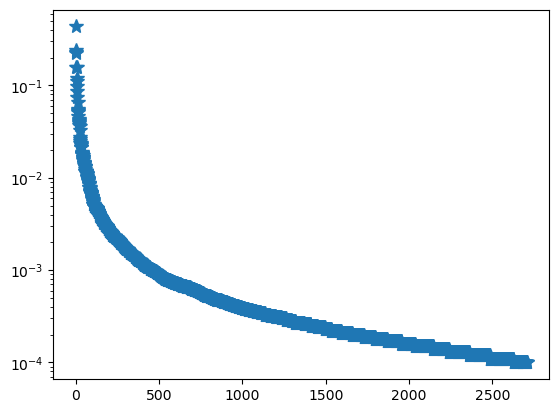

In [135]:
stateIndex = 50

plt.plot(np.sort(state[stateIndex])[::-1]**1,'*')
plt.yscale('log')

print(np.sum(state[stateIndex]))